<a href="https://colab.research.google.com/github/ilfpns/PhoSem/blob/main/AnomalyDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Library 호출
import re
import time
import shutil
from collections import Counter
from pathlib import Path
from google.colab import drive
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
import torchvision
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import io
import fnmatch
import unicodedata
from torch.utils.data import Subset
from sklearn.metrics import  average_precision_score, roc_curve, precision_recall_curve



In [2]:
# 정상 데이터 확인 (300_data/남은_2142장, 868x868) + 드라이브 목록 확인
FORCE_REMOUNT = True
MOUNT_ROOT = Path("/content/drive/MyDrive")
SHOW_DIRS = [MOUNT_ROOT, MOUNT_ROOT / "300_data", MOUNT_ROOT / "300_data" / "banks"]
MAX_LIST = 30

if FORCE_REMOUNT:
    drive.mount("/content/drive", force_remount=True)
elif not MOUNT_ROOT.exists():
    drive.mount("/content/drive")

def entry_info(p):
    form = "NFC" if p.name == unicodedata.normalize("NFC", p.name) else "NFD"
    try:
        if p.is_dir():
            n_items = sum(1 for _ in p.iterdir())
            return form, "폴더", f"{n_items:,}개 항목", "-"
        size = p.stat().st_size
        with open(p, "rb") as f:
            f.read(1)
        return form, "파일", f"{size:,} bytes", "읽기 OK"
    except OSError as e:
        return form, "?", "-", f"읽기 실패 ({e.__class__.__name__})"

print("마운트된 드라이브 목록")
for d in SHOW_DIRS:
    print("")
    print(f"[{d}]")
    if not d.exists():
        print("  (없음)")
        continue
    items = sorted(d.iterdir(), key=lambda p: (not p.is_dir(), p.name))
    for p in items[:MAX_LIST]:
        form, kind, size, status = entry_info(p)
        print(f"  {form}  {kind:<3} {size:>16}  {status:<22} {p.name}")
    if len(items) > MAX_LIST:
        print(f"  ... 외 {len(items) - MAX_LIST:,}개")
print("")

DRIVE_DIR = Path("/content/drive/MyDrive/300_data/남은_2142장")
LOCAL_DIR = Path("/content/normal_data")
IMG_SIZE = 868
BATCH_SIZE = 16
EXPECTED_N = 2142
EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
NAME_PATTERN = re.compile(r"^R\d+_-?\d+_-?\d+$")

if not DRIVE_DIR.exists():
    raise FileNotFoundError(f"경로 없음: {DRIVE_DIR}")

LOCAL_DIR.mkdir(parents=True, exist_ok=True)
src_files = sorted(p for p in DRIVE_DIR.iterdir() if p.is_file() and p.suffix.lower() in EXTS)
for p in src_files:
    dst = LOCAL_DIR / p.name
    if not dst.exists():
        shutil.copy2(p, dst)

all_paths = sorted(p for p in LOCAL_DIR.iterdir() if p.is_file() and p.suffix.lower() in EXTS)
skipped = [p.name for p in all_paths if not NAME_PATTERN.match(p.stem)]
normal_paths = [p for p in all_paths if NAME_PATTERN.match(p.stem)]
if len(normal_paths) != EXPECTED_N:
    raise RuntimeError(f"정상 풀 장수 불일치: {len(normal_paths)} != {EXPECTED_N}")

size_counter = Counter()
for p in normal_paths:
    with Image.open(p) as im:
        size_counter[(im.width, im.height, im.mode)] += 1

class NormalDataset(Dataset):
    def __init__(self, paths, size):
        self.paths = paths
        self.tf = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.tf(img), self.paths[idx].name

normal_ds = NormalDataset(normal_paths, IMG_SIZE)
normal_loader = DataLoader(normal_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

x, names = next(iter(normal_loader))
print(f"드라이브 원본: {len(src_files):,}장")
print(f"로컬 복사본: {len(all_paths):,}장")
print(f"패턴 밖 제외: {skipped}")
print(f"정상 풀: {len(normal_paths):,}장")
print(f"원본 크기/모드 분포: {dict(size_counter)}")
print(f"배치 shape: {tuple(x.shape)}")
print(f"예시 파일: {names[:3]}")

Mounted at /content/drive
마운트된 드라이브 목록

[/content/drive/MyDrive]
  NFC  폴더             9개 항목  -                      300_data
  NFC  폴더             1개 항목  -                      Colab Notebooks
  NFC  파일      97,534 bytes  읽기 OK                  ERICA-code.zip
  NFD  ?                  -  읽기 실패 (OSError)        Pixel_RnD_Result_Presentation 최종.gslides
  NFC  ?                  -  읽기 실패 (OSError)        Pixel_RnD_Result_Presentation.gslides
  NFD  ?                  -  읽기 실패 (OSError)        Pixel_RnD_Result_Presentation의 사본 (1).gslides
  NFD  ?                  -  읽기 실패 (OSError)        Pixel_RnD_Result_Presentation의 사본.gslides
  NFC  파일  333,424,331 bytes  읽기 OK                  demo.zip
  NFC  파일  438,472,707 bytes  읽기 OK                  demo2.zip
  NFD  파일  15,701,343 bytes  읽기 OK                  결과보고서_Nonamed.pptx
  NFD  ?                  -  읽기 실패 (OSError)        까치집·전봇대 데이터셋 EDA 체크리스트.gsheet

[/content/drive/MyDrive/300_data]
  NFC  폴더      

In [ ]:
# 특징 개수 및 메모리 뱅크 크기 확인 (868x868, 장당 표본)
import torch
import torchvision

IMG_SIZE = 868
PATCHES_PER_IMG = 1000
MAX_BANK = 100_000
FEAT_DIM = 1024
PROJ_DIM = 128
EXPECTED_N = 2142

N_NORMAL = len(normal_paths)
if N_NORMAL != EXPECTED_N:
    raise RuntimeError(f"정상 풀 장수 불일치: {N_NORMAL} != {EXPECTED_N}")

backbone = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2).eval()
feats = {}
backbone.layer2.register_forward_hook(lambda m, i, o: feats.__setitem__("l2", o))
backbone.layer3.register_forward_hook(lambda m, i, o: feats.__setitem__("l3", o))

with torch.no_grad():
    backbone(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE))

c2, h2, w2 = feats["l2"].shape[1:]
c3, h3, w3 = feats["l3"].shape[1:]
dim = c2 + c3
patches_per_img = h2 * w2
k = min(PATCHES_PER_IMG, patches_per_img)
total_full = patches_per_img * N_NORMAL
total_cand = k * N_NORMAL
bank = min(total_cand, MAX_BANK)

def mb(n, d, bytes_per):
    return n * d * bytes_per / 1024**2

print(f"정상 이미지: {N_NORMAL:,}장 / 입력: {IMG_SIZE}x{IMG_SIZE}")
print(f"layer2: {c2}x{h2}x{w2}")
print(f"layer3: {c3}x{h3}x{w3}")
print(f"패치 차원: {dim} -> 축소 {FEAT_DIM}")
print(f"이미지당 패치: {patches_per_img:,}")
print("")
print(f"[전체 사용 시] 전체 패치: {total_full:,}")
print(f"[전체 사용 시] 특징 (float16, {FEAT_DIM}d): {mb(total_full, FEAT_DIM, 2):,.0f} MB")
print("")
print(f"[장당 표본] 장당 {k:,}개 ({k / patches_per_img:.1%}) / 후보: {total_cand:,}")
print(f"[장당 표본] 후보 특징 (float16, {FEAT_DIM}d, CPU): {mb(total_cand, FEAT_DIM, 2):,.0f} MB")
print(f"[장당 표본] 코어셋용 투영 (float32, {PROJ_DIM}d, GPU): {mb(total_cand, PROJ_DIM, 4):,.0f} MB")
print(f"메모리 뱅크: {bank:,} (후보 대비 {bank / total_cand:.1%}, 전체 대비 {bank / total_full:.2%})")
print(f"최종 뱅크 (float16, {FEAT_DIM}d): {mb(bank, FEAT_DIM, 2):,.0f} MB")

In [ ]:
# 메모리 뱅크 구축 v2 (868x868, 장당 표본, 이미지 인덱스 저장)
if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/300_data/남은_2142장")
LOCAL_DIR = Path("/content/normal_data")
OUT_DIR = Path("/content/drive/MyDrive/300_data/banks")
IMG_SIZE = 868
BATCH_SIZE = 16
PATCHES_PER_IMG = 1000
MAX_BANK = 100_000
FEAT_DIM = 1024
PROJ_DIM = 128
BANK_MODE = "coreset"
EXCLUDE_NAMES = set()
RUN_TAG = "ex0"
SEED = 0
EXPECTED_N = 2142
EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
NAME_PATTERN = re.compile(r"^R\d+_-?\d+_-?\d+$")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    raise RuntimeError("GPU 런타임으로 바꿔서 실행하세요")
if BANK_MODE not in {"coreset", "random"}:
    raise ValueError(f"BANK_MODE 오류: {BANK_MODE}")
torch.manual_seed(SEED)
gen = torch.Generator().manual_seed(SEED)

if not DRIVE_DIR.exists():
    raise FileNotFoundError(f"경로 없음: {DRIVE_DIR}")
LOCAL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

src_files = sorted(p for p in DRIVE_DIR.iterdir() if p.is_file() and p.suffix.lower() in EXTS)
for p in src_files:
    dst = LOCAL_DIR / p.name
    if not dst.exists():
        shutil.copy2(p, dst)

all_paths = sorted(p for p in LOCAL_DIR.iterdir() if p.is_file() and p.suffix.lower() in EXTS)
skipped = [p.name for p in all_paths if not NAME_PATTERN.match(p.stem)]
valid_paths = [p for p in all_paths if NAME_PATTERN.match(p.stem)]
if len(valid_paths) != EXPECTED_N:
    raise RuntimeError(f"정상 풀 장수 불일치: {len(valid_paths)} != {EXPECTED_N}")
unknown_ex = EXCLUDE_NAMES - {p.stem for p in valid_paths}
if unknown_ex:
    raise RuntimeError(f"풀에 없는 제외 이름: {sorted(unknown_ex)[:10]}")
bank_paths = [p for p in valid_paths if p.stem not in EXCLUDE_NAMES]
bank_names = [p.stem for p in bank_paths]
print(f"정상 풀: {len(valid_paths):,}장 / 패턴 밖 제외: {skipped} / 정제 제외: {len(EXCLUDE_NAMES):,}장 / 뱅크 사용: {len(bank_paths):,}장")

class ImageSet(Dataset):
    def __init__(self, paths, size):
        self.paths = paths
        self.tf = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.tf(img), idx

loader = DataLoader(ImageSet(bank_paths, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

backbone = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2).eval().to(device)

def embed_map(x):
    x = backbone.maxpool(backbone.relu(backbone.bn1(backbone.conv1(x))))
    l2 = backbone.layer2(backbone.layer1(x))
    l3 = backbone.layer3(l2)
    l2 = F.avg_pool2d(l2, 3, 1, 1, count_include_pad=False)
    l3 = F.avg_pool2d(l3, 3, 1, 1, count_include_pad=False)
    l3 = F.interpolate(l3, size=l2.shape[-2:], mode="bilinear", align_corners=False)
    f = torch.cat([l2, l3], 1)
    b, c, h, w = f.shape
    return f.permute(0, 2, 3, 1).reshape(b, h * w, c), h, w

def reduce_dim(f):
    return F.adaptive_avg_pool1d(f.unsqueeze(1), FEAT_DIM).squeeze(1)

with torch.no_grad():
    _, fh, fw = embed_map(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device))

hw = fh * fw
k = min(PATCHES_PER_IMG, hw)
total = k * len(bank_paths)
all_feats = torch.empty((total, FEAT_DIM), dtype=torch.float16)
all_img = torch.empty(total, dtype=torch.int32)
all_pos = torch.empty(total, dtype=torch.int32)
proj_mat = (torch.randn(FEAT_DIM, PROJ_DIM, generator=gen) / PROJ_DIM ** 0.5).to(device)
all_proj = torch.empty((total, PROJ_DIM), dtype=torch.float32, device=device)

print(f"입력: {IMG_SIZE}x{IMG_SIZE} / 특징맵: {fh}x{fw} = {hw:,}조각 / 장당 표본: {k:,} / 후보 전체: {total:,}")

t0 = time.time()
ptr = 0
with torch.no_grad():
    for x, idx in tqdm(loader, desc="특징 추출"):
        fm, _, _ = embed_map(x.to(device, non_blocking=True))
        b, _, c = fm.shape
        sel = torch.stack([torch.randperm(hw, generator=gen)[:k] for _ in range(b)]).to(device)
        picked = torch.gather(fm, 1, sel.unsqueeze(-1).expand(-1, -1, c)).reshape(-1, c)
        f = reduce_dim(picked)
        n = f.shape[0]
        all_feats[ptr:ptr + n] = f.half().cpu()
        all_proj[ptr:ptr + n] = f @ proj_mat
        all_img[ptr:ptr + n] = idx.repeat_interleave(k).to(torch.int32)
        all_pos[ptr:ptr + n] = sel.reshape(-1).cpu().to(torch.int32)
        ptr += n

if ptr != total:
    raise RuntimeError(f"조각 수 불일치: {ptr} != {total}")
print(f"특징 추출 완료: {time.time() - t0:.0f}초")

t0 = time.time()
n_select = min(MAX_BANK, total)
if BANK_MODE == "coreset":
    sq = (all_proj ** 2).sum(1)
    selected = torch.empty(n_select, dtype=torch.long, device=device)
    min_dist = torch.full((total,), float("inf"), device=device)
    cur = torch.randint(total, (1,), generator=gen).to(device)[0]
    with torch.no_grad():
        for i in tqdm(range(n_select), desc="코어셋 선택", mininterval=2):
            selected[i] = cur
            d = sq - 2 * (all_proj @ all_proj[cur]) + sq[cur]
            min_dist = torch.minimum(min_dist, d)
            cur = torch.argmax(min_dist)
    coverage = min_dist.clamp_min(0).max().sqrt().item()
    sel_cpu = selected.cpu()
    del sq, min_dist, selected
else:
    sel_cpu = torch.randperm(total, generator=gen)[:n_select]
    coverage = float("nan")
print(f"{BANK_MODE} 선택 완료: {time.time() - t0:.0f}초")

del all_proj
torch.cuda.empty_cache()

memory_bank = all_feats[sel_cpu].clone()
bank_img_idx = all_img[sel_cpu].clone()
bank_pos = all_pos[sel_cpu].clone()
n_unique = torch.unique(sel_cpu).numel()
per_img = torch.bincount(bank_img_idx.long(), minlength=len(bank_paths))
del all_feats, all_img, all_pos

save_path = OUT_DIR / f"bank_{IMG_SIZE}_{BANK_MODE}_{RUN_TAG}.pt"
torch.save({
    "memory_bank": memory_bank,
    "bank_img_idx": bank_img_idx,
    "bank_pos": bank_pos,
    "names": bank_names,
    "excluded": sorted(EXCLUDE_NAMES),
    "config": {
        "backbone": "resnet50_imagenet1k_v2",
        "layers": ["layer2", "layer3"],
        "img_size": IMG_SIZE,
        "feat_map": [fh, fw],
        "patches_per_img": k,
        "max_bank": MAX_BANK,
        "feat_dim": FEAT_DIM,
        "proj_dim": PROJ_DIM,
        "bank_mode": BANK_MODE,
        "run_tag": RUN_TAG,
        "seed": SEED,
        "n_images": len(bank_paths),
        "total_candidates": total,
        "coverage": coverage,
    },
}, save_path)

print(f"메모리 뱅크: {tuple(memory_bank.shape)} / 중복 없는 선택: {n_unique:,}")
print(f"샘플링 비율(후보 대비): {n_select / total:.1%} / 커버 반경(투영 공간): {coverage:.4f}")
print(f"사진당 뱅크 조각: 최소 {per_img.min().item()} / 중앙 {per_img.median().item()} / 최대 {per_img.max().item()} / 0개인 사진 {(per_img == 0).sum().item()}장")
print(f"저장: {save_path}")

In [ ]:
BANK_FILE = OUT_DIR / "bank_868_coreset_ex0.pt"
SCORE_BATCH = 4
Q_CHUNK = 2048
TOP_K = 12

if not BANK_FILE.exists():
    raise FileNotFoundError(f"뱅크 없음: {BANK_FILE}")
bank = torch.load(BANK_FILE, map_location="cpu")
cfg = bank["config"]
if cfg["img_size"] != IMG_SIZE or list(cfg["feat_map"]) != [fh, fw] or cfg["feat_dim"] != FEAT_DIM:
    raise RuntimeError(f"설정 불일치: 뱅크 {cfg['img_size']}, {cfg['feat_map']}, {cfg['feat_dim']} / 현재 {IMG_SIZE}, {[fh, fw]}, {FEAT_DIM}")

bank_feats = bank["memory_bank"].float().to(device)
bank_sq = (bank_feats ** 2).sum(1)
bank_owner = bank["bank_img_idx"].long().to(device)
name_to_bankidx = {nm: i for i, nm in enumerate(bank["names"])}
bank_count = torch.bincount(bank["bank_img_idx"].long(), minlength=len(bank["names"]))

pool_paths = list(valid_paths)
pool_names = [p.stem for p in pool_paths]
self_ids = [name_to_bankidx.get(nm, -1) for nm in pool_names]
print(f"뱅크: {BANK_FILE.name} / {tuple(bank_feats.shape)} / 뱅크 사진 {len(bank['names']):,}장 / 제외 {len(bank['excluded']):,}장")
print(f"채점 대상: {len(pool_paths):,}장 / 자기 조각이 뱅크에 있는 사진: {sum(s >= 0 for s in self_ids):,}장")

def nn_dist(q, self_id):
    ex = torch.empty(q.shape[0], device=device)
    noex = torch.empty(q.shape[0], device=device)
    self_cols = (bank_owner == self_id).nonzero(as_tuple=True)[0] if self_id >= 0 else None
    for s in range(0, q.shape[0], Q_CHUNK):
        qc = q[s:s + Q_CHUNK]
        d = qc @ bank_feats.T
        d.mul_(-2).add_(bank_sq.unsqueeze(0)).add_((qc ** 2).sum(1, keepdim=True))
        noex[s:s + Q_CHUNK] = d.min(1).values
        if self_cols is not None and self_cols.numel() > 0:
            d[:, self_cols] = float("inf")
        ex[s:s + Q_CHUNK] = d.min(1).values
    return ex.clamp_min(0).sqrt(), noex.clamp_min(0).sqrt()

score_loader = DataLoader(ImageSet(pool_paths, IMG_SIZE), batch_size=SCORE_BATCH, shuffle=False, num_workers=2, pin_memory=True)

n_pool = len(pool_paths)
score_max = np.zeros(n_pool, dtype=np.float32)
score_topk = np.zeros(n_pool, dtype=np.float32)
score_max_noex = np.zeros(n_pool, dtype=np.float32)
max_pos = np.zeros(n_pool, dtype=np.int64)
maps = torch.empty((n_pool, fh, fw), dtype=torch.float16)

t0 = time.time()
with torch.no_grad():
    for x, idx in tqdm(score_loader, desc="Outlier 채점"):
        fm, _, _ = embed_map(x.to(device, non_blocking=True))
        b, _, c = fm.shape
        q_all = reduce_dim(fm.reshape(-1, c)).reshape(b, hw, FEAT_DIM)
        for j in range(b):
            i = idx[j].item()
            ex, noex = nn_dist(q_all[j], self_ids[i])
            score_max[i] = ex.max().item()
            score_topk[i] = torch.topk(ex, TOP_K).values.mean().item()
            score_max_noex[i] = noex.max().item()
            max_pos[i] = ex.argmax().item()
            maps[i] = ex.reshape(fh, fw).half().cpu()
print(f"채점 완료: {time.time() - t0:.0f}초")

topk_col = f"점수_상위{TOP_K}평균"
df_out = pd.DataFrame({
    "대표": pool_names,
    "점수_최댓값": score_max,
    topk_col: score_topk,
    "점수_최댓값_자기포함": score_max_noex,
    "뱅크조각수": [int(bank_count[s]) if s >= 0 else 0 for s in self_ids],
    "최대위치_y": max_pos // fw,
    "최대위치_x": max_pos % fw,
})
df_out["순위_최댓값"] = df_out["점수_최댓값"].rank(ascending=False, method="first").astype(int)
df_out[f"순위_상위{TOP_K}"] = df_out[topk_col].rank(ascending=False, method="first").astype(int)

tag = BANK_FILE.stem.replace("bank_", "")
csv_path = OUT_DIR / f"outlier_scores_{tag}.csv"
map_path = OUT_DIR / f"outlier_maps_{tag}.pt"
df_out.to_csv(csv_path, index=False, encoding="utf-8-sig")
torch.save({"maps": maps, "names": pool_names, "feat_map": [fh, fw], "bank_file": str(BANK_FILE)}, map_path)

ok_order = bool((score_max_noex <= score_max + 1e-4).all())
print(f"자기 제외 확인: 자기포함 <= 자기제외 전부 성립 = {ok_order} / 평균 비율 {np.mean(score_max_noex / np.maximum(score_max, 1e-8)):.3f}")
print(f"점수_최댓값 vs {topk_col} (Spearman): {df_out['점수_최댓값'].corr(df_out[topk_col], method='spearman'):.3f}")
print(f"뱅크조각수 vs {topk_col} (Spearman): {df_out['뱅크조각수'].corr(df_out[topk_col], method='spearman'):.3f}")
print("")
print(df_out[[topk_col, "점수_최댓값"]].describe(percentiles=[0.5, 0.9, 0.97, 0.99]).round(4))
print("")
print(df_out.sort_values(f"순위_상위{TOP_K}").head(20)[["대표", topk_col, "점수_최댓값", "뱅크조각수", "최대위치_y", "최대위치_x"]].to_string(index=False))
print("")
print(f"저장: {csv_path}")
print(f"저장: {map_path}")

In [ ]:
OUT_DIR = Path("/content/drive/MyDrive/300_data/banks")
OUT_CSV = OUT_DIR / "outlier_scores_868_coreset_ex0.csv"
OUT_MAPS = OUT_DIR / "outlier_maps_868_coreset_ex0.pt"
SCORE_COL = "점수_상위12평균"
EDGE = 2

if not Path("/content/drive/MyDrive").exists():
    from google.colab import drive
    drive.mount("/content/drive")
if not OUT_CSV.exists():
    raise FileNotFoundError(f"결과 없음: {OUT_CSV}")

fh, fw = torch.load(OUT_MAPS, map_location="cpu")["feat_map"] if OUT_MAPS.exists() else (109, 109)
res = pd.read_csv(OUT_CSV)
res["가장자리"] = (res["최대위치_y"] < EDGE) | (res["최대위치_y"] >= fh - EDGE) | (res["최대위치_x"] < EDGE) | (res["최대위치_x"] >= fw - EDGE)
base_rate = (fh * fw - (fh - 2 * EDGE) * (fw - 2 * EDGE)) / (fh * fw)

order = res.sort_values(SCORE_COL, ascending=False).reset_index(drop=True)
print(f"특징맵 {fh}x{fw} / 최대위치가 가장자리 {EDGE}칸 이내인 비율 (위치가 무작위라면 {base_rate:.1%})")
for frac in [0.01, 0.03, 0.10, 0.20, 1.0]:
    k = max(1, int(round(len(order) * frac)))
    print(f"  상위 {frac:>4.0%} ({k:>4}장): {order['가장자리'][:k].mean():.1%}")

parts = res["대표"].str.extract(r"^R(\d+)_(-?\d+)_(-?\d+)$").astype(int)
res["웨이퍼"] = parts[0]
res["좌표1"] = parts[1]
res["좌표2"] = parts[2]

k3 = int(round(len(res) * 0.03))
top_names = set(order["대표"][:k3])
res["상위3%"] = res["대표"].isin(top_names)
summary = res.groupby("웨이퍼").agg(장수=("대표", "size"), 평균점수=(SCORE_COL, "mean"), 상위3퍼센트=("상위3%", "sum"))
summary["상위3퍼센트_비율"] = summary["상위3퍼센트"] / summary["장수"]
print("")
print(f"웨이퍼별 (상위 3% = {k3}장)")
print(summary.round(3).to_string())

wafers = sorted(res["웨이퍼"].unique())
fig, axes = plt.subplots(1, len(wafers), figsize=(5 * len(wafers), 5), squeeze=False)
vmin, vmax = res[SCORE_COL].quantile(0.05), res[SCORE_COL].quantile(0.99)
for ax, w in zip(axes[0], wafers):
    sub = res[res["웨이퍼"] == w]
    sc = ax.scatter(sub["좌표2"], sub["좌표1"], c=sub[SCORE_COL], cmap="viridis", vmin=vmin, vmax=vmax, s=14)
    top = sub[sub["상위3%"]]
    ax.scatter(top["좌표2"], top["좌표1"], facecolors="none", edgecolors="red", s=60, linewidths=1.2)
    ax.set_title(f"R{w} (n={len(sub)}, top3%={len(top)})")
    ax.set_xlabel("2nd index")
    ax.set_ylabel("1st index")
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes[0].tolist(), shrink=0.8, label="score (top12 mean)")
plt.show()

In [ ]:
# 상위 사진 + 이상 맵 겹쳐 보기
OUT_DIR = Path("/content/drive/MyDrive/300_data/banks")
DRIVE_DIR = Path("/content/drive/MyDrive/300_data/남은_2142장")
LOCAL_DIR = Path("/content/normal_data")
OUT_CSV = OUT_DIR / "outlier_scores_868_coreset_ex0.csv"
OUT_MAPS = OUT_DIR / "outlier_maps_868_coreset_ex0.pt"
SCORE_COL = "점수_상위12평균"
EDGE = 2
SHOW_N = 16
MODE = "R1"

if not Path("/content/drive/MyDrive").exists():
    from google.colab import drive
    drive.mount("/content/drive")

res = pd.read_csv(OUT_CSV)
mp = torch.load(OUT_MAPS, map_location="cpu")
maps = mp["maps"].float()
fh, fw = mp["feat_map"]
name_to_i = {nm: i for i, nm in enumerate(mp["names"])}

res["가장자리"] = (res["최대위치_y"] < EDGE) | (res["최대위치_y"] >= fh - EDGE) | (res["최대위치_x"] < EDGE) | (res["최대위치_x"] >= fw - EDGE)
res["웨이퍼"] = res["대표"].str.extract(r"^R(\d+)_")[0].astype(int)
order = res.sort_values(SCORE_COL, ascending=False)

if MODE == "top":
    pick = order
elif MODE == "edge":
    pick = order[order["가장자리"]]
elif MODE == "interior":
    pick = order[~order["가장자리"]]
elif MODE.startswith("R") and MODE[1:].isdigit():
    pick = order[order["웨이퍼"] == int(MODE[1:])]
else:
    raise ValueError(f"MODE 오류: {MODE}")
pick = pick.head(SHOW_N).reset_index(drop=True)

flat = maps.flatten()
sample = flat[torch.randint(flat.numel(), (2_000_000,))].numpy()
vmin, vmax = np.percentile(sample, 50), np.percentile(sample, 99.9)

def find_img(stem):
    for d in [LOCAL_DIR, DRIVE_DIR]:
        hits = sorted(d.glob(f"{stem}.*")) if d.exists() else []
        if hits:
            return hits[0]
    raise FileNotFoundError(stem)

cols = 4
rows = int(np.ceil(len(pick) / cols))
fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 2 * 2.4, rows * 3.3), squeeze=False)
for k, r in pick.iterrows():
    ax0 = axes[k // cols][(k % cols) * 2]
    ax1 = axes[k // cols][(k % cols) * 2 + 1]
    img = np.asarray(Image.open(find_img(r["대표"])).convert("RGB"))
    H, W = img.shape[:2]
    m = maps[name_to_i[r["대표"]]][None, None]
    m_up = F.interpolate(m, size=(H, W), mode="bilinear", align_corners=False)[0, 0].numpy()
    px = (r["최대위치_x"] + 0.5) * W / fw
    py = (r["최대위치_y"] + 0.5) * H / fh
    ax0.imshow(img)
    ax1.imshow(img)
    ax1.imshow(m_up, cmap="jet", alpha=0.45, vmin=vmin, vmax=vmax)
    ax1.scatter([px], [py], marker="x", c="white", s=60, linewidths=2)
    ax0.set_title(f"#{k + 1} {r['대표']}", fontsize=8)
    ax1.set_title(f"{r[SCORE_COL]:.2f} edge={bool(r['가장자리'])}", fontsize=8)
    ax0.axis("off")
    ax1.axis("off")
for k in range(len(pick), rows * cols):
    axes[k // cols][(k % cols) * 2].axis("off")
    axes[k // cols][(k % cols) * 2 + 1].axis("off")
plt.suptitle(f"MODE={MODE} / top {len(pick)}", fontsize=11)
plt.tight_layout()
plt.show()

print(pick[["대표", "웨이퍼", SCORE_COL, "점수_최댓값", "뱅크조각수", "최대위치_y", "최대위치_x", "가장자리"]].to_string(index=False))

In [14]:
# 제외 목록 만들기 (Outlier 점수 + MIL 점수)
ROOT = Path("/content/drive/MyDrive")
DATA_DIR = ROOT / "300_data"
OUT_DIR = DATA_DIR / "banks"
OUT_CSV = OUT_DIR / "outlier_scores_868_coreset_ex0.csv"
ITAM_CSV = DATA_DIR / "261008_이탐점수_3609장.csv"
MIL_CSV = None
MIL_SEARCH_DIRS = [DATA_DIR, ROOT / "3609", ROOT]
MIL_PATTERN = "3609_개선_전체순위_*.csv"
MIL_SCORE_KEYS = ["불량확률", "종합점수"]
PC_COL = "점수_상위12평균"
PCTS = [3, 10, 20, 30]
LIST_PATH = OUT_DIR / "exclusion_lists_ex0.csv"

if not ROOT.exists():
    from google.colab import drive
    drive.mount("/content/drive")
for p in [OUT_CSV, ITAM_CSV]:
    if not p.is_file():
        raise FileNotFoundError(f"파일 없음: {p}")

def nfc(s):
    return unicodedata.normalize("NFC", s)

def find_candidates(dirs, pattern):
    pat = nfc(pattern)
    found = []
    for d in dirs:
        if not d.exists():
            continue
        for p in sorted(d.iterdir()):
            if p.is_file() and fnmatch.fnmatch(nfc(p.name), pat):
                found.append(p)
    return found

def read_bytes(p):
    try:
        with open(p, "rb") as f:
            data = f.read()
        return data if data else None
    except OSError:
        return None

mil_bytes = None
tried = []
candidates = [Path(MIL_CSV)] if MIL_CSV else find_candidates(MIL_SEARCH_DIRS, MIL_PATTERN)
for c in candidates:
    data = read_bytes(c)
    tried.append((str(c), data is not None))
    if data is not None:
        MIL_CSV, mil_bytes = c, data
        break
for path_str, ok in tried:
    print(f"후보: {path_str} -> {'읽기 성공' if ok else '읽기 실패'}")
if mil_bytes is None:
    listing = [nfc(p.name) for p in DATA_DIR.iterdir() if p.suffix.lower() == ".csv"] if DATA_DIR.exists() else []
    raise FileNotFoundError(f"MIL 순위표를 읽지 못했습니다. 300_data의 csv 목록: {listing}")
print(f"MIL 순위표: {MIL_CSV} ({len(mil_bytes):,} bytes)")

itam = pd.read_csv(ITAM_CSV)
mil = pd.read_csv(io.BytesIO(mil_bytes), encoding="utf-8-sig")
mil.columns = [nfc(c).strip() for c in mil.columns]
print(f"MIL 순위표 열: {list(mil.columns)} / {len(mil):,}행")
if "일련번호" not in mil.columns:
    raise RuntimeError("MIL 순위표에 일련번호 열이 없습니다")
mil_col = next((c for key in MIL_SCORE_KEYS for c in mil.columns if key in c), None)
if mil_col is None:
    raise RuntimeError(f"MIL 점수 열을 찾지 못했습니다: {list(mil.columns)}")
if mil["일련번호"].duplicated().any():
    raise RuntimeError("MIL 순위표에 중복 일련번호가 있습니다")
name_col = next((c for c in mil.columns if "사진명" in c), None)
print(f"MIL 점수 열: {mil_col}")

keep = ["일련번호", mil_col] + ([name_col] if name_col else [])
full = itam[["일련번호", "대표", "판정"]].merge(mil[keep], on="일련번호", how="left").rename(columns={mil_col: "MIL점수"})
if full["MIL점수"].isna().any():
    raise RuntimeError(f"MIL 점수가 없는 사진 {int(full['MIL점수'].isna().sum())}장")
if name_col:
    mismatch = int((full[name_col].astype(str).map(nfc).str.strip() != full["대표"]).sum())
    print(f"일련번호 연결 확인 (MIL 사진명 vs 교수님 대표 불일치): {mismatch}장")
    if mismatch:
        raise RuntimeError("일련번호로 연결한 사진 이름이 서로 다릅니다")

judged = full[full["판정"].isin(["불량", "양품"])]
if len(judged) != 1467 or (judged["판정"] == "불량").sum() != 882:
    raise RuntimeError(f"판정 행 확인 실패: {len(judged)}행, 불량 {(judged['판정'] == '불량').sum()}")
mil_auc = roc_auc_score((judged["판정"] == "불량").astype(int), judged["MIL점수"])
print(f"MIL 점수 방향 확인 (1,467장 AUROC, 0.5보다 커야 함): {mil_auc:.3f}")
if mil_auc < 0.5:
    raise RuntimeError("MIL 점수가 '클수록 정상' 방향입니다. 부호를 확인하세요")

pc = pd.read_csv(OUT_CSV)[["대표", PC_COL]].rename(columns={PC_COL: "PC점수"})
df = pc.merge(full[full["판정"].isna()][["대표", "일련번호", "MIL점수"]], on="대표", how="left")
if len(df) != 2142 or df["MIL점수"].isna().any():
    raise RuntimeError(f"2,142장 매칭 실패: {len(df)}행, MIL 없음 {int(df['MIL점수'].isna().sum())}")
df["R"] = df["대표"].str.extract(r"^R(\d+)_")[0].astype(int)
n = len(df)

df["PC순위"] = df["PC점수"].rank(pct=True)
df["MIL순위"] = df["MIL점수"].rank(pct=True)
df["순위평균"] = (df["PC순위"] + df["MIL순위"]) / 2
df["PC순위_R내"] = df.groupby("R")["PC점수"].rank(pct=True)
df["MIL순위_R내"] = df.groupby("R")["MIL점수"].rank(pct=True)
df["순위평균_R내"] = (df["PC순위_R내"] + df["MIL순위_R내"]) / 2
df["순위차_PC빼기MIL"] = df["PC순위"] - df["MIL순위"]

print(f"2,142장에서 PatchCore vs MIL 순위 상관 (Spearman): {df['PC점수'].corr(df['MIL점수'], method='spearman'):.3f}")

pc_order = df.sort_values("PC점수", ascending=False)["대표"].tolist()
mil_order = df.sort_values("MIL점수", ascending=False)["대표"].tolist()

def top_by(col, k):
    return set(df.sort_values(col, ascending=False)["대표"].iloc[:k])

def by_r(p):
    s = set()
    for _, g in df.groupby("R"):
        k = int(round(len(g) * p / 100))
        s |= set(g.sort_values("순위평균_R내", ascending=False)["대표"].iloc[:k])
    return s

def or_matched(k):
    s = set()
    for m in range(n):
        s.add(pc_order[m])
        s.add(mil_order[m])
        if len(s) >= k:
            return s
    return s

lists = {}
for p in PCTS:
    k = int(round(n * p / 100))
    lists[f"rankavg_{p}"] = top_by("순위평균", k)
    lists[f"byR_{p}"] = by_r(p)
    lists[f"or_{p}"] = or_matched(k)

for name, s in lists.items():
    df[name] = df["대표"].isin(s)

r_vals = sorted(df["R"].unique())
rows = []
for name, s in lists.items():
    sub = df[df[name]]
    rows.append({"목록": name, "제외장수": len(sub), **{f"R{r}": int((sub["R"] == r).sum()) for r in r_vals}})
rows.append({"목록": "전체(참고)", "제외장수": n, **{f"R{r}": int((df["R"] == r).sum()) for r in r_vals}})
summary = pd.DataFrame(rows)
print("")
print("제외 목록 요약 (R별 제외 장수)")
print(summary.to_string(index=False))

show_cols = ["대표", "R", "PC점수", "MIL점수", "PC순위", "MIL순위"]
print("")
print("PatchCore만 높게 본 사진 (드문 정상 또는 처음 보는 결함 후보) 상위 15")
print(df.sort_values("순위차_PC빼기MIL", ascending=False)[show_cols].head(15).round(3).to_string(index=False))
print("")
print("MIL만 높게 본 사진 (반복 결함 후보) 상위 15")
print(df.sort_values("순위차_PC빼기MIL", ascending=True)[show_cols].head(15).round(3).to_string(index=False))

df.to_csv(LIST_PATH, index=False, encoding="utf-8-sig")
print("")
print(f"저장: {LIST_PATH}")

후보: /content/drive/MyDrive/300_data/3609_개선_전체순위_20260929_144906.csv -> 읽기 성공
MIL 순위표: /content/drive/MyDrive/300_data/3609_개선_전체순위_20260929_144906.csv (132,597 bytes)
MIL 순위표 열: ['순위', '일련번호', '원본_사진명', '종합점수(100점)', 'MIL_불량확률(%)', '이상점수', '기존_순위(셀36)', '상위900'] / 3,609행
MIL 점수 열: MIL_불량확률(%)
일련번호 연결 확인 (MIL 사진명 vs 교수님 대표 불일치): 0장
MIL 점수 방향 확인 (1,467장 AUROC, 0.5보다 커야 함): 0.596
2,142장에서 PatchCore vs MIL 순위 상관 (Spearman): -0.048

제외 목록 요약 (R별 제외 장수)
        목록  제외장수   R1  R2  R3  R4
 rankavg_3    64   40   1   8  15
     byR_3    64   52   0   5   7
      or_3    64   38   1   4  21
rankavg_10   214  164   1  12  37
    byR_10   215  174   1  18  22
     or_10   214  127   3  16  68
rankavg_20   428  331   2  31  64
    byR_20   429  347   2  36  44
     or_20   428  289   4  31 104
rankavg_30   643  511   4  49  79
    byR_30   642  521   3  53  65
     or_30   643  449   7  54 133
    전체(참고)  2142 1736  10 178 218

PatchCore만 높게 본 사진 (드문 정상 또는 처음 보는 결함 후보) 상위 15
    

In [4]:
# 메모리 뱅크 구축 v2 (868x868, 장당 표본, 이미지 인덱스 저장, 정렬 표식 4장 제외)
if not Path("/content/drive/MyDrive").exists():
    drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/300_data/남은_2142장")
LOCAL_DIR = Path("/content/normal_data")
OUT_DIR = Path("/content/drive/MyDrive/300_data/banks")
IMG_SIZE = 868
BATCH_SIZE = 16
PATCHES_PER_IMG = 1000
MAX_BANK = 100_000
FEAT_DIM = 1024
PROJ_DIM = 128
BANK_MODE = "coreset"
EXCLUDE_NAMES = {"R4_2_39", "R4_2_41", "R4_-1_4", "R4_-1_38"}
RUN_TAG = "nomark"
SEED = 0
EXPECTED_N = 2142
EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
NAME_PATTERN = re.compile(r"^R\d+_-?\d+_-?\d+$")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    raise RuntimeError("GPU 런타임으로 바꿔서 실행하세요")
if BANK_MODE not in {"coreset", "random"}:
    raise ValueError(f"BANK_MODE 오류: {BANK_MODE}")
torch.manual_seed(SEED)
gen = torch.Generator().manual_seed(SEED)

if not DRIVE_DIR.exists():
    raise FileNotFoundError(f"경로 없음: {DRIVE_DIR}")
LOCAL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

src_files = sorted(p for p in DRIVE_DIR.iterdir() if p.is_file() and p.suffix.lower() in EXTS)
for p in src_files:
    dst = LOCAL_DIR / p.name
    if not dst.exists():
        shutil.copy2(p, dst)

all_paths = sorted(p for p in LOCAL_DIR.iterdir() if p.is_file() and p.suffix.lower() in EXTS)
skipped = [p.name for p in all_paths if not NAME_PATTERN.match(p.stem)]
valid_paths = [p for p in all_paths if NAME_PATTERN.match(p.stem)]
if len(valid_paths) != EXPECTED_N:
    raise RuntimeError(f"정상 풀 장수 불일치: {len(valid_paths)} != {EXPECTED_N}")
unknown_ex = EXCLUDE_NAMES - {p.stem for p in valid_paths}
if unknown_ex:
    raise RuntimeError(f"풀에 없는 제외 이름: {sorted(unknown_ex)[:10]}")
bank_paths = [p for p in valid_paths if p.stem not in EXCLUDE_NAMES]
bank_names = [p.stem for p in bank_paths]
print(f"정상 풀: {len(valid_paths):,}장 / 패턴 밖 제외: {skipped} / 정제 제외: {len(EXCLUDE_NAMES):,}장 {sorted(EXCLUDE_NAMES)} / 뱅크 사용: {len(bank_paths):,}장")

class ImageSet(Dataset):
    def __init__(self, paths, size):
        self.paths = paths
        self.tf = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.tf(img), idx

loader = DataLoader(ImageSet(bank_paths, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

backbone = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2).eval().to(device)

def embed_map(x):
    x = backbone.maxpool(backbone.relu(backbone.bn1(backbone.conv1(x))))
    l2 = backbone.layer2(backbone.layer1(x))
    l3 = backbone.layer3(l2)
    l2 = F.avg_pool2d(l2, 3, 1, 1, count_include_pad=False)
    l3 = F.avg_pool2d(l3, 3, 1, 1, count_include_pad=False)
    l3 = F.interpolate(l3, size=l2.shape[-2:], mode="bilinear", align_corners=False)
    f = torch.cat([l2, l3], 1)
    b, c, h, w = f.shape
    return f.permute(0, 2, 3, 1).reshape(b, h * w, c), h, w

def reduce_dim(f):
    return F.adaptive_avg_pool1d(f.unsqueeze(1), FEAT_DIM).squeeze(1)

with torch.no_grad():
    _, fh, fw = embed_map(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device))

hw = fh * fw
k = min(PATCHES_PER_IMG, hw)
total = k * len(bank_paths)
all_feats = torch.empty((total, FEAT_DIM), dtype=torch.float16)
all_img = torch.empty(total, dtype=torch.int32)
all_pos = torch.empty(total, dtype=torch.int32)
proj_mat = (torch.randn(FEAT_DIM, PROJ_DIM, generator=gen) / PROJ_DIM ** 0.5).to(device)
all_proj = torch.empty((total, PROJ_DIM), dtype=torch.float32, device=device)

print(f"입력: {IMG_SIZE}x{IMG_SIZE} / 특징맵: {fh}x{fw} = {hw:,}조각 / 장당 표본: {k:,} / 후보 전체: {total:,}")

t0 = time.time()
ptr = 0
with torch.no_grad():
    for x, idx in tqdm(loader, desc="특징 추출"):
        fm, _, _ = embed_map(x.to(device, non_blocking=True))
        b, _, c = fm.shape
        sel = torch.stack([torch.randperm(hw, generator=gen)[:k] for _ in range(b)]).to(device)
        picked = torch.gather(fm, 1, sel.unsqueeze(-1).expand(-1, -1, c)).reshape(-1, c)
        f = reduce_dim(picked)
        n = f.shape[0]
        all_feats[ptr:ptr + n] = f.half().cpu()
        all_proj[ptr:ptr + n] = f @ proj_mat
        all_img[ptr:ptr + n] = idx.repeat_interleave(k).to(torch.int32)
        all_pos[ptr:ptr + n] = sel.reshape(-1).cpu().to(torch.int32)
        ptr += n

if ptr != total:
    raise RuntimeError(f"조각 수 불일치: {ptr} != {total}")
print(f"특징 추출 완료: {time.time() - t0:.0f}초")

t0 = time.time()
n_select = min(MAX_BANK, total)
if BANK_MODE == "coreset":
    sq = (all_proj ** 2).sum(1)
    selected = torch.empty(n_select, dtype=torch.long, device=device)
    min_dist = torch.full((total,), float("inf"), device=device)
    cur = torch.randint(total, (1,), generator=gen).to(device)[0]
    with torch.no_grad():
        for i in tqdm(range(n_select), desc="코어셋 선택", mininterval=2):
            selected[i] = cur
            d = sq - 2 * (all_proj @ all_proj[cur]) + sq[cur]
            min_dist = torch.minimum(min_dist, d)
            cur = torch.argmax(min_dist)
    coverage = min_dist.clamp_min(0).max().sqrt().item()
    sel_cpu = selected.cpu()
    del sq, min_dist, selected
else:
    sel_cpu = torch.randperm(total, generator=gen)[:n_select]
    coverage = float("nan")
print(f"{BANK_MODE} 선택 완료: {time.time() - t0:.0f}초")

del all_proj
torch.cuda.empty_cache()

memory_bank = all_feats[sel_cpu].clone()
bank_img_idx = all_img[sel_cpu].clone()
bank_pos = all_pos[sel_cpu].clone()
n_unique = torch.unique(sel_cpu).numel()
per_img = torch.bincount(bank_img_idx.long(), minlength=len(bank_paths))
del all_feats, all_img, all_pos

save_path = OUT_DIR / f"bank_{IMG_SIZE}_{BANK_MODE}_{RUN_TAG}.pt"
torch.save({
    "memory_bank": memory_bank,
    "bank_img_idx": bank_img_idx,
    "bank_pos": bank_pos,
    "names": bank_names,
    "excluded": sorted(EXCLUDE_NAMES),
    "config": {
        "backbone": "resnet50_imagenet1k_v2",
        "layers": ["layer2", "layer3"],
        "img_size": IMG_SIZE,
        "feat_map": [fh, fw],
        "patches_per_img": k,
        "max_bank": MAX_BANK,
        "feat_dim": FEAT_DIM,
        "proj_dim": PROJ_DIM,
        "bank_mode": BANK_MODE,
        "run_tag": RUN_TAG,
        "seed": SEED,
        "n_images": len(bank_paths),
        "total_candidates": total,
        "coverage": coverage,
    },
}, save_path)

print(f"메모리 뱅크: {tuple(memory_bank.shape)} / 중복 없는 선택: {n_unique:,}")
print(f"샘플링 비율(후보 대비): {n_select / total:.1%} / 커버 반경(투영 공간): {coverage:.4f}")
print(f"사진당 뱅크 조각: 최소 {per_img.min().item()} / 중앙 {per_img.median().item()} / 최대 {per_img.max().item()} / 0개인 사진 {(per_img == 0).sum().item()}장")
print(f"저장: {save_path}")

정상 풀: 2,142장 / 패턴 밖 제외: ['R1_-18_21 (1).PNG'] / 정제 제외: 4장 ['R4_-1_38', 'R4_-1_4', 'R4_2_39', 'R4_2_41'] / 뱅크 사용: 2,138장
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


입력: 868x868 / 특징맵: 109x109 = 11,881조각 / 장당 표본: 1,000 / 후보 전체: 2,138,000


특징 추출:   0%|          | 0/134 [00:00<?, ?it/s]

특징 추출 완료: 115초


코어셋 선택:   0%|          | 0/100000 [00:00<?, ?it/s]

coreset 선택 완료: 952초
메모리 뱅크: (100000, 1024) / 중복 없는 선택: 100,000
샘플링 비율(후보 대비): 4.7% / 커버 반경(투영 공간): 7.0693
사진당 뱅크 조각: 최소 10 / 중앙 38 / 최대 444 / 0개인 사진 0장
저장: /content/drive/MyDrive/300_data/banks/bank_868_coreset_nomark.pt


In [5]:
# 1,467장 채점 (Novelty, 20%마다 저장 및 이어하기)

BANK_FILE = OUT_DIR / "bank_868_coreset_nomark.pt"
ITAM_CSV = Path("/content/drive/MyDrive/300_data/261008_이탐점수_3609장.csv")
TEST_DIR = None
SEARCH_ROOT = Path("/content/drive/MyDrive")
SEARCH_DEPTH = 2
TEST_LOCAL = Path("/content/test1467")
SCORE_BATCH = 4
Q_CHUNK = 2048
TOP_K = 12
SAVE_FRAC = 0.2
EXPECTED_TEST = 1467

def nfc(s):
    return unicodedata.normalize("NFC", s)

if not BANK_FILE.exists():
    raise FileNotFoundError(f"뱅크 없음: {BANK_FILE}")
bank = torch.load(BANK_FILE, map_location="cpu")
cfg = bank["config"]
if cfg["img_size"] != IMG_SIZE or list(cfg["feat_map"]) != [fh, fw] or cfg["feat_dim"] != FEAT_DIM:
    raise RuntimeError(f"설정 불일치: 뱅크 {cfg['img_size']}, {cfg['feat_map']}, {cfg['feat_dim']} / 현재 {IMG_SIZE}, {[fh, fw]}, {FEAT_DIM}")
bank_feats = bank["memory_bank"].float().to(device)
bank_sq = (bank_feats ** 2).sum(1)
print(f"뱅크: {BANK_FILE.name} / {tuple(bank_feats.shape)} / 뱅크 사진 {len(bank['names']):,}장 / 제외 {bank['excluded']}")

itam = pd.read_csv(ITAM_CSV)
test_meta = itam[itam["판정"].isin(["불량", "양품"])][["일련번호", "대표", "판정"]].reset_index(drop=True)
if len(test_meta) != EXPECTED_TEST:
    raise RuntimeError(f"판정 행 수 불일치: {len(test_meta)} != {EXPECTED_TEST}")
need = set(test_meta["대표"])
overlap = need & set(bank["names"])
if overlap:
    raise RuntimeError(f"채점 대상이 뱅크에 들어 있습니다: {sorted(overlap)[:10]}")

def scan_for_dir(root, depth):
    best_hits, best_dir = 0, None
    stack = [(root, 0)]
    while stack:
        d, lv = stack.pop()
        try:
            entries = list(d.iterdir())
        except OSError:
            continue
        hits = sum(1 for p in entries if p.suffix.lower() in EXTS and nfc(p.stem) in need)
        if hits > best_hits:
            best_hits, best_dir = hits, d
        if lv < depth:
            for p in entries:
                try:
                    if p.is_dir():
                        stack.append((p, lv + 1))
                except OSError:
                    pass
    return best_dir, best_hits

if TEST_DIR is None:
    TEST_DIR, found_hits = scan_for_dir(SEARCH_ROOT, SEARCH_DEPTH)
    if TEST_DIR is None:
        raise FileNotFoundError("1,467장 사진 폴더를 찾지 못했습니다. TEST_DIR에 경로를 직접 넣으세요")
    print(f"1,467장 폴더 자동 탐색: {TEST_DIR} ({found_hits:,}장 이름 일치)")
TEST_DIR = Path(TEST_DIR)

src_map = {}
for p in sorted(TEST_DIR.iterdir()):
    if p.suffix.lower() in EXTS:
        stem = nfc(p.stem)
        if stem in need and stem not in src_map:
            src_map[stem] = p
missing = sorted(need - set(src_map))
if missing:
    raise RuntimeError(f"{TEST_DIR}에 없는 사진 {len(missing)}장: {missing[:10]}")

TEST_LOCAL.mkdir(parents=True, exist_ok=True)
test_paths = []
for nm in test_meta["대표"]:
    src = src_map[nm]
    dst = TEST_LOCAL / f"{nm}{src.suffix.lower()}"
    if not dst.exists():
        shutil.copy2(src, dst)
    test_paths.append(dst)
size_counter = Counter()
for p in test_paths[:50]:
    with Image.open(p) as im:
        size_counter[(im.width, im.height, im.mode)] += 1
print(f"채점 대상: {len(test_paths):,}장 (불량 {(test_meta['판정'] == '불량').sum()} / 양품 {(test_meta['판정'] == '양품').sum()}) / 앞 50장 크기 분포: {dict(size_counter)}")

tag = BANK_FILE.stem.replace("bank_", "")
csv_path = OUT_DIR / f"test1467_scores_{tag}.csv"
map_path = OUT_DIR / f"test1467_maps_{tag}.pt"
ckpt_path = OUT_DIR / f"test1467_ckpt_{tag}.pt"
test_names = test_meta["대표"].tolist()
n_test = len(test_paths)

score_max = np.zeros(n_test, dtype=np.float32)
score_topk = np.zeros(n_test, dtype=np.float32)
max_pos = np.zeros(n_test, dtype=np.int64)
maps = torch.zeros((n_test, fh, fw), dtype=torch.float16)
done = np.zeros(n_test, dtype=bool)

if ckpt_path.exists():
    ck = torch.load(ckpt_path, map_location="cpu")
    if ck["bank_file"] != BANK_FILE.name or ck["names"] != test_names or list(ck["feat_map"]) != [fh, fw]:
        raise RuntimeError(f"체크포인트가 현재 설정과 다릅니다. 지우고 다시 실행하세요: {ckpt_path}")
    score_max = ck["score_max"].numpy().copy()
    score_topk = ck["score_topk"].numpy().copy()
    max_pos = ck["max_pos"].numpy().copy()
    maps = ck["maps"].clone()
    done = ck["done"].numpy().copy()
    print(f"이어하기: {int(done.sum()):,}/{n_test:,}장 완료된 체크포인트를 불러왔습니다")

def save_ckpt():
    tmp_path = ckpt_path.with_suffix(".tmp")
    torch.save({
        "score_max": torch.from_numpy(score_max),
        "score_topk": torch.from_numpy(score_topk),
        "max_pos": torch.from_numpy(max_pos),
        "maps": maps,
        "done": torch.from_numpy(done),
        "names": test_names,
        "bank_file": BANK_FILE.name,
        "feat_map": [fh, fw],
    }, tmp_path)
    tmp_path.replace(ckpt_path)

def nn_dist_plain(q):
    out = torch.empty(q.shape[0], device=device)
    for s in range(0, q.shape[0], Q_CHUNK):
        qc = q[s:s + Q_CHUNK]
        d = qc @ bank_feats.T
        d.mul_(-2).add_(bank_sq.unsqueeze(0)).add_((qc ** 2).sum(1, keepdim=True))
        out[s:s + Q_CHUNK] = d.min(1).values
    return out.clamp_min(0).sqrt()

todo = np.where(~done)[0].tolist()
save_every = max(1, int(np.ceil(n_test * SAVE_FRAC)))
next_mark = (int(done.sum()) // save_every + 1) * save_every

if todo:
    score_loader = DataLoader(Subset(ImageSet(test_paths, IMG_SIZE), todo), batch_size=SCORE_BATCH, shuffle=False, num_workers=2, pin_memory=True)
    t0 = time.time()
    with torch.no_grad():
        for x, idx in tqdm(score_loader, desc="1,467장 채점"):
            fm, _, _ = embed_map(x.to(device, non_blocking=True))
            b, _, c = fm.shape
            q_all = reduce_dim(fm.reshape(-1, c)).reshape(b, hw, FEAT_DIM)
            for j in range(b):
                i = idx[j].item()
                dist = nn_dist_plain(q_all[j])
                score_max[i] = dist.max().item()
                score_topk[i] = torch.topk(dist, TOP_K).values.mean().item()
                max_pos[i] = dist.argmax().item()
                maps[i] = dist.reshape(fh, fw).half().cpu()
                done[i] = True
            n_done = int(done.sum())
            if n_done >= next_mark and n_done < n_test:
                save_ckpt()
                tqdm.write(f"체크포인트 저장: {n_done:,}/{n_test:,} ({n_done / n_test:.0%}) / 이번 실행 경과 {time.time() - t0:.0f}초")
                next_mark += save_every
    print(f"채점 완료: 이번 실행 {time.time() - t0:.0f}초")

if not done.all():
    raise RuntimeError(f"미완료: {int(done.sum())}/{n_test}")
save_ckpt()

topk_col = f"점수_상위{TOP_K}평균"
out = test_meta.copy()
out["점수_최댓값"] = score_max
out[topk_col] = score_topk
out["최대위치_y"] = max_pos // fw
out["최대위치_x"] = max_pos % fw
out.to_csv(csv_path, index=False, encoding="utf-8-sig")
torch.save({"maps": maps, "names": test_names, "feat_map": [fh, fw], "bank_file": str(BANK_FILE)}, map_path)

print("")
print(out[[topk_col, "점수_최댓값"]].describe(percentiles=[0.5, 0.9, 0.99]).round(4))
print("")
print(f"저장: {csv_path}")
print(f"저장: {map_path}")

뱅크: bank_868_coreset_nomark.pt / (100000, 1024) / 뱅크 사진 2,138장 / 제외 ['R4_-1_38', 'R4_-1_4', 'R4_2_39', 'R4_2_41']
1,467장 폴더 자동 탐색: /content/drive/MyDrive/300_data/판정_1467 (1,467장 이름 일치)
채점 대상: 1,467장 (불량 882 / 양품 585) / 앞 50장 크기 분포: {(339, 450, 'RGB'): 50}


1,467장 채점:   0%|          | 0/367 [00:00<?, ?it/s]

체크포인트 저장: 296/1,467 (20%) / 이번 실행 경과 275초
체크포인트 저장: 588/1,467 (40%) / 이번 실행 경과 542초
체크포인트 저장: 884/1,467 (60%) / 이번 실행 경과 814초
체크포인트 저장: 1,176/1,467 (80%) / 이번 실행 경과 1081초
채점 완료: 이번 실행 1346초

       점수_상위12평균     점수_최댓값
count  1467.0000  1467.0000
mean     10.2159    10.7468
std       2.3294     2.4738
min       7.5578     7.6809
50%       9.2647     9.8839
90%      13.8096    14.4686
99%      15.3307    16.1460
max      16.8196    17.9063

저장: /content/drive/MyDrive/300_data/banks/test1467_scores_868_coreset_nomark.csv
저장: /content/drive/MyDrive/300_data/banks/test1467_maps_868_coreset_nomark.pt


행 수: 1,467 (불량 882 / 양품 585) / 빈칸: {'새축_상위12평균': 0, '새축_최댓값': 0, 'MIL점수': 0, '이탐_점수': 0}
[검증] 이탐 AUROC 0.779 (기대 0.779) / AP 0.873 (기대 0.873)
[검증] MIL AUROC 0.596 (기대 0.596)
[검증] 이탐 작동점 {'상위10%': '147/147 검출 16.7% 정밀 100.0%', '상위25%': '358/367 검출 40.6% 정밀 97.5%', '검출95%_검사량': '1335 (91%)', '불량_최저순위': 1466} (기대: 상위10% 147/147, 상위25% 358/367, 검출95% 1335, 최저 1466)

1,467장 (불량 882 / 양품 585, 불량률 0.601) 기준 성능
          점수  AUROC         95% CI    AP                      상위10%                     상위25%  검출95%_검사량  불량_최저순위
새 축 (상위12평균)  0.802 [0.781, 0.823] 0.872  141/147 검출 16.0% 정밀 95.9% 359/367 검출 40.7% 정밀 97.8% 1301 (89%)     1462
   새 축 (최댓값)  0.796 [0.771, 0.818] 0.871  141/147 검출 16.0% 정밀 95.9% 358/367 검출 40.6% 정밀 97.5% 1317 (90%)     1465
         MIL  0.596 [0.569, 0.625] 0.746  140/147 검출 15.9% 정밀 95.2% 305/367 검출 34.6% 정밀 83.1% 1412 (96%)     1467
  결합 (w=0.8)  0.805 [0.782, 0.826] 0.882  143/147 검출 16.2% 정밀 97.3% 359/367 검출 40.7% 정밀 97.8% 1322 (90%)     1467
 교수님 이탐 (참고)  0.779 [0.

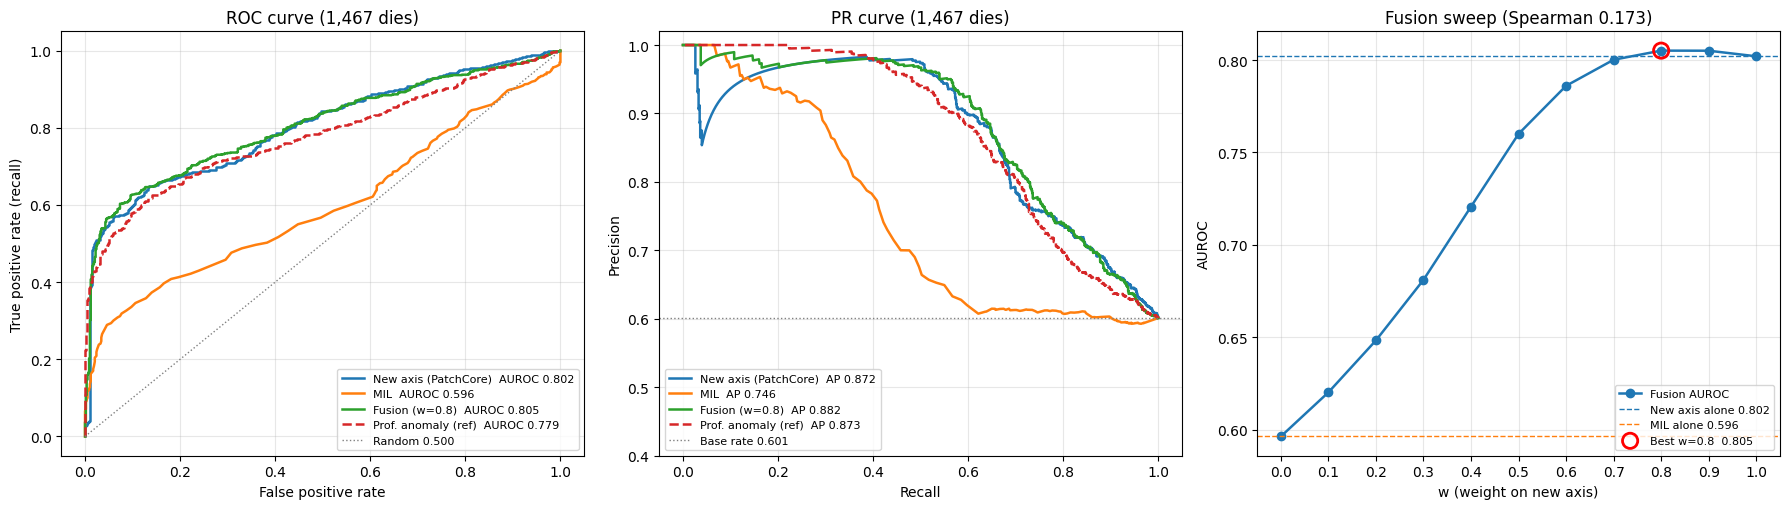

저장: /content/drive/MyDrive/300_data/banks/fusion_table_nomark.csv
저장: /content/drive/MyDrive/300_data/banks/fusion_w_sweep_nomark.csv
저장: /content/drive/MyDrive/300_data/banks/fusion_summary_nomark.csv
저장: /content/drive/MyDrive/300_data/banks/fusion_curves_nomark.png


In [6]:
# 6~7단계: 새 축 + MIL 결합, AUROC·상관·ROC/PR 곡선
ROOT = Path("/content/drive/MyDrive")
DATA_DIR = ROOT / "300_data"
OUT_DIR = DATA_DIR / "banks"
BANK_CSV = OUT_DIR / "test1467_scores_868_coreset_nomark.csv"
MIL_CSV = DATA_DIR / "3609_개선_전체순위_20260929_144906.csv"
ANOMALY_CSV = DATA_DIR / "261008_이탐점수_3609장.csv"
TAG = "nomark"
NEW_COL = "새축_상위12평균"
W_GRID = np.round(np.arange(0.0, 1.0001, 0.1), 1)
N_BOOT = 2000
SEED = 0
MARKS_IN_TEST = ["R4_2_3", "R4_2_1", "R4_-1_2"]

if not ROOT.exists():
    from google.colab import drive
    drive.mount("/content/drive")
for p in [BANK_CSV, MIL_CSV, ANOMALY_CSV]:
    if not p.is_file():
        raise FileNotFoundError(f"파일 없음: {p}")

bank_df = pd.read_csv(BANK_CSV)
mil_df = pd.read_csv(MIL_CSV, encoding="utf-8-sig")
mil_df.columns = [c.strip() for c in mil_df.columns]
anomaly_df = pd.read_csv(ANOMALY_CSV)

parsed_bank = bank_df[["일련번호", "대표", "판정", "점수_상위12평균", "점수_최댓값", "최대위치_y", "최대위치_x"]].rename(
    columns={"점수_상위12평균": "새축_상위12평균", "점수_최댓값": "새축_최댓값"}
)
parsed_mil = mil_df[["일련번호", "MIL_불량확률(%)"]].rename(columns={"MIL_불량확률(%)": "MIL점수"})
parsed_anomaly = anomaly_df[["일련번호", "이탐_점수"]]

result = (
    parsed_bank
    .merge(parsed_mil, on="일련번호", how="left", validate="one_to_one")
    .merge(parsed_anomaly, on="일련번호", how="left", validate="one_to_one")
)

n_def = int((result["판정"] == "불량").sum())
n_ok = int((result["판정"] == "양품").sum())
missing = result[["새축_상위12평균", "새축_최댓값", "MIL점수", "이탐_점수"]].isna().sum()
print(f"행 수: {len(result):,} (불량 {n_def} / 양품 {n_ok}) / 빈칸: {missing.to_dict()}")
if len(result) != 1467 or n_def != 882 or n_ok != 585 or missing.any():
    raise RuntimeError("합친 표 확인 실패: 행 수나 빈칸을 확인하세요")

y = (result["판정"] == "불량").astype(int).to_numpy()
base_rate = y.mean()
rng = np.random.default_rng(SEED)

def auc_ci(scores):
    s = np.asarray(scores)
    vals = []
    for _ in range(N_BOOT):
        idx = rng.integers(0, len(y), len(y))
        if y[idx].min() == y[idx].max():
            continue
        vals.append(roc_auc_score(y[idx], s[idx]))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return lo, hi

def op_points(scores):
    order = np.argsort(-np.asarray(scores), kind="mergesort")
    ys = y[order]
    n, npos = len(ys), int(ys.sum())
    cum = np.cumsum(ys)
    out = {}
    for frac in [0.10, 0.25]:
        k = int(round(n * frac))
        det = int(cum[k - 1])
        out[f"상위{int(frac * 100)}%"] = f"{det}/{k} 검출 {det / npos:.1%} 정밀 {det / k:.1%}"
    k95 = int(np.searchsorted(cum, int(np.ceil(0.95 * npos))) + 1)
    out["검출95%_검사량"] = f"{k95} ({k95 / n:.0%})"
    out["불량_최저순위"] = int(np.where(ys == 1)[0].max() + 1)
    return out

auc_itam = roc_auc_score(y, result["이탐_점수"])
ap_itam = average_precision_score(y, result["이탐_점수"])
auc_mil = roc_auc_score(y, result["MIL점수"])
print(f"[검증] 이탐 AUROC {auc_itam:.3f} (기대 0.779) / AP {ap_itam:.3f} (기대 0.873)")
print(f"[검증] MIL AUROC {auc_mil:.3f} (기대 0.596)")
print(f"[검증] 이탐 작동점 {op_points(result['이탐_점수'])} (기대: 상위10% 147/147, 상위25% 358/367, 검출95% 1335, 최저 1466)")
if abs(auc_itam - 0.779) > 0.003 or abs(ap_itam - 0.873) > 0.003 or abs(auc_mil - 0.596) > 0.003:
    raise RuntimeError("검증 실패: 계산 방식이나 열 연결을 확인하세요")

result["새축순위"] = result[NEW_COL].rank(pct=True)
result["MIL순위"] = result["MIL점수"].rank(pct=True)

sweep_rows = []
for w in W_GRID:
    fused = w * result["새축순위"] + (1 - w) * result["MIL순위"]
    sweep_rows.append({"w": w, "AUROC": roc_auc_score(y, fused), "AP": average_precision_score(y, fused)})
sweep_df = pd.DataFrame(sweep_rows)

auc_new = roc_auc_score(y, result[NEW_COL])
if abs(sweep_df.loc[sweep_df["w"] == 0.0, "AUROC"].item() - auc_mil) > 1e-9 or abs(sweep_df.loc[sweep_df["w"] == 1.0, "AUROC"].item() - auc_new) > 1e-9:
    raise RuntimeError("결합 확인 실패: w=0은 MIL, w=1은 새 축과 AUROC가 같아야 합니다")

best = sweep_df.loc[sweep_df["AUROC"].idxmax()]
best_w = float(best["w"])
result["결합점수"] = best_w * result["새축순위"] + (1 - best_w) * result["MIL순위"]
spearman = result[NEW_COL].corr(result["MIL점수"], method="spearman")

score_cols = [
    ("새 축 (상위12평균)", NEW_COL),
    ("새 축 (최댓값)", "새축_최댓값"),
    ("MIL", "MIL점수"),
    (f"결합 (w={best_w:.1f})", "결합점수"),
    ("교수님 이탐 (참고)", "이탐_점수"),
]
rows = []
for label, col in score_cols:
    lo, hi = auc_ci(result[col])
    rows.append({
        "점수": label,
        "AUROC": round(roc_auc_score(y, result[col]), 3),
        "95% CI": f"[{lo:.3f}, {hi:.3f}]",
        "AP": round(average_precision_score(y, result[col]), 3),
        **op_points(result[col]),
    })
summary_df = pd.DataFrame(rows)

print("")
print(f"1,467장 (불량 {n_def} / 양품 {n_ok}, 불량률 {base_rate:.3f}) 기준 성능")
print(summary_df.to_string(index=False))
print("")
print("w별 결합 성능 (w = 새 축 비중)")
print(sweep_df.round(4).to_string(index=False))

new_rank = result[NEW_COL].rank(ascending=False, method="min")
mark_info = [f"{nm} {int(new_rank[result['대표'] == nm].iloc[0])}위" for nm in MARKS_IN_TEST if (result["대표"] == nm).any()]
print("")
print(f"정렬 표식 순위 (새 축, 1,467장 중): {', '.join(mark_info)}")

print("")
print("정리")
print(f"  1. 새 축 혼자의 AUROC: {auc_new:.3f}")
print(f"  2. 두 점수의 상관 (Spearman): {spearman:.3f}")
print(f"  3. 가장 좋은 w: {best_w:.1f} / 그때의 AUROC: {best['AUROC']:.3f}")
if spearman < 0.3:
    corr_note = "상관 0.3 미만: 합치면 오를 여지가 큰 조합"
elif spearman > 0.6:
    corr_note = "상관 0.6 초과: 합쳐도 거의 안 오를 조합"
else:
    corr_note = "상관 0.3~0.6: 중간"
print(f"  해석: {corr_note}")
if best["AUROC"] <= auc_new + 1e-3:
    print("  해석: 결합이 새 축 혼자보다 낫지 않음 → 교수님 말씀대로 새 축만 써도 됨")
else:
    print(f"  해석: 결합이 새 축 혼자보다 {best['AUROC'] - auc_new:+.3f} 높음")
print("  주의: w는 1,467장으로 골랐으므로 이 AUROC는 성능 주장이 아니라 설정 선택용 숫자")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
curve_set = [
    ("New axis (PatchCore)", result[NEW_COL], "-"),
    ("MIL", result["MIL점수"], "-"),
    (f"Fusion (w={best_w:.1f})", result["결합점수"], "-"),
    ("Prof. anomaly (ref)", result["이탐_점수"], "--"),
]
for name, s, ls in curve_set:
    fpr, tpr, _ = roc_curve(y, s)
    axes[0].plot(fpr, tpr, ls, lw=1.8, label=f"{name}  AUROC {roc_auc_score(y, s):.3f}")
    prec, rec, _ = precision_recall_curve(y, s)
    axes[1].plot(rec, prec, ls, lw=1.8, label=f"{name}  AP {average_precision_score(y, s):.3f}")
axes[0].plot([0, 1], [0, 1], ":", color="gray", lw=1, label="Random 0.500")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate (recall)")
axes[0].set_title("ROC curve (1,467 dies)")
axes[0].legend(loc="lower right", fontsize=8)
axes[1].axhline(base_rate, ls=":", color="gray", lw=1, label=f"Base rate {base_rate:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("PR curve (1,467 dies)")
axes[1].set_ylim(0.4, 1.02)
axes[1].legend(loc="lower left", fontsize=8)
axes[2].plot(sweep_df["w"], sweep_df["AUROC"], "o-", lw=1.8, label="Fusion AUROC")
axes[2].axhline(auc_new, ls="--", color="tab:blue", lw=1, label=f"New axis alone {auc_new:.3f}")
axes[2].axhline(auc_mil, ls="--", color="tab:orange", lw=1, label=f"MIL alone {auc_mil:.3f}")
axes[2].scatter([best_w], [best["AUROC"]], s=120, facecolors="none", edgecolors="red", linewidths=2, zorder=5, label=f"Best w={best_w:.1f}  {best['AUROC']:.3f}")
axes[2].set_xlabel("w (weight on new axis)")
axes[2].set_ylabel("AUROC")
axes[2].set_title(f"Fusion sweep (Spearman {spearman:.3f})")
axes[2].set_xticks(W_GRID)
axes[2].legend(loc="lower right", fontsize=8)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()

fig_path = OUT_DIR / f"fusion_curves_{TAG}.png"
table_path = OUT_DIR / f"fusion_table_{TAG}.csv"
sweep_path = OUT_DIR / f"fusion_w_sweep_{TAG}.csv"
summary_path = OUT_DIR / f"fusion_summary_{TAG}.csv"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

result.to_csv(table_path, index=False, encoding="utf-8-sig")
sweep_df.to_csv(sweep_path, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")
print(f"저장: {table_path}")
print(f"저장: {sweep_path}")
print(f"저장: {summary_path}")
print(f"저장: {fig_path}")